In [1]:
# Import libries
import numpy as np
import pandas as pd
import os
import re
import glob
import json
import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyranges as pr
import pysam
# from scipy.stats import mannwhitneyu, stats
# from statannotations.Annotator import Annotator

current_directory = os.getcwd()
print("Current Directory:", current_directory)
pd.set_option("display.max_columns", None)


Current Directory: /mnt/NAS3/home/jiwon/ECTRES/python


In [2]:
# find -L /mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/results/align_dna/GRCh37 -name "*.bam" -exec realpath {} + > /mnt/NAS3/home/jiwon/ECTRES/data/bam_list_all_origin.txt

In [8]:
# 파일 경로 설정
file_path = '/mnt/NAS3/home/jiwon/ECTRES/data/bam_list_all_origin.txt'

# 파일 읽기
with open(file_path, 'r') as f:
    bam_paths = f.read().splitlines()

data = []
for path in bam_paths:
    # 경로를 'GRCh37/' 기준으로 나누어 그 바로 뒤의 폴더명을 가져옵니다.
    # 예: .../GRCh37/ECTRES-XXXX/applyBqsr/... -> ECTRES-XXXX
    try:
        barcode = path.split('GRCh37/')[1].split('/')[0]
        data.append({'aliquot_barcode': barcode, 'bam': path})
    except IndexError:
        # 경로 형식이 다를 경우를 대비한 예외 처리
        print(f"경로 형식이 맞지 않음: {path}")

# 3. 데이터프레임 생성
df = pd.DataFrame(data)

# 4. 결과 확인
print(f"총 {len(df)}개의 샘플이 로드되었습니다.")
display(df.head())

총 77개의 샘플이 로드되었습니다.


,aliquot_barcode,bam
0,ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985,/mnt/NAS3/home/mary/HL-NF/scratch/ECTRES/resul...
1,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,/mnt/NAS3/home/mary/HL-NF/scratch/ECTRES/resul...
2,ECTRES-ECGI1-0001-TPX-A02-WGS-5KM079,/mnt/NAS3/home/mary/HL-NF/scratch/ECTRES/resul...
3,ECTRES-ECGI1-0001-TPX-A03-WGS-0LT586,/mnt/NAS3/home/mary/HL-NF/scratch/ECTRES/resul...
4,ECTRES-ECGI1-0001-TPX-A04-WGS-0SR571,/mnt/NAS3/home/mary/HL-NF/scratch/ECTRES/resul...


In [14]:
manifest=pd.read_csv('../manifest/ECTRES_clones_nf_dna_fastqs_20260303.csv')
manifest.head(2)

manifest["sample_id"] = manifest["sample_legacy_id"].fillna("parental")
bam_manifest = manifest[['aliquot_barcode', 'source_barcode', 'sample_barcode',
       'patient_barcode', 'sample_type', 'tumor_or_normal', 'sequence_type',
       'sample_legacy_id', 'gender','action', 'sample_id']].drop_duplicates()

print(manifest.shape, sample_mapping.shape) #(87, 19) (77, 5)
print(manifest.shape, bam_manifest.shape) #(87, 19) (77, 11)

(87, 19) (77, 5)
(87, 19) (77, 11)


In [15]:
bam_manifest.groupby('source_barcode').size()

source_barcode
ECGI1    34
EFM19    11
H2170    32
dtype: int64

In [17]:
bam_manifest= pd.merge(bam_manifest, df, on='aliquot_barcode', how='left')

In [19]:
bam_manifest['bai']=bam_manifest['bam']+'.bai'

In [28]:
bam_manifest.head(2)

,aliquot_barcode,source_barcode,sample_barcode,patient_barcode,sample_type,tumor_or_normal,sequence_type,sample_legacy_id,gender,action,sample_id,bam,bai
0,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,ECGI1,ECTRES-ECGI1-0001-TPX-A01,ECTRES-ECGI1-0001,TP,tumor,WGS,EG_1,XY,NaN,EG_1,/mnt/NAS3/home/mary/HL-NF/scratch/ECTRES/resul...,/mnt/NAS3/home/mary/HL-NF/scratch/ECTRES/resul...
1,ECTRES-ECGI1-0001-TPX-A10-WGS-3SW949,ECGI1,ECTRES-ECGI1-0001-TPX-A10,ECTRES-ECGI1-0001,TP,tumor,WGS,EG_10,XY,NaN,EG_10,/mnt/NAS3/home/mary/HL-NF/scratch/ECTRES/resul...,/mnt/NAS3/home/mary/HL-NF/scratch/ECTRES/resul...


In [39]:
bam_manifest[bam_manifest['sample_id']=='parental']

,aliquot_barcode,source_barcode,sample_barcode,patient_barcode,sample_type,tumor_or_normal,sequence_type,sample_legacy_id,gender,action,sample_id,bam,bai
50,ECTRES-H2170-0001-TPX-A01-WGS-3YV111,H2170,ECTRES-H2170-0001-TPX-A01,ECTRES-H2170-0001,TP,tumor,WGS,NaN,XY,NaN,parental,/mnt/NAS3/home/mary/HL-NF/scratch/ECTRES/resul...,/mnt/NAS3/home/mary/HL-NF/scratch/ECTRES/resul...
51,ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985,ECGI1,ECTRES-ECGI1-0001-TPX-A01,ECTRES-ECGI1-0001,TP,tumor,WGS,NaN,XY,NaN,parental,/mnt/NAS3/home/mary/HL-NF/scratch/ECTRES/resul...,/mnt/NAS3/home/mary/HL-NF/scratch/ECTRES/resul...
52,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,EFM19,ECTRES-EFM19-0001-TPX-A01,ECTRES-EFM19-0001,TP,tumor,WGS,NaN,XX,NaN,parental,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...


In [23]:
# bam_manifest.to_csv('../manifest/ECTRES_clones_nf_dna_bam.csv',index=False)  ## 20260309
# bam_manifest.to_csv('/mnt/NAS3/home/jiwon/ECTRES/manifest/ECTRES_clones_nf_dna_bam.csv',index=False)  ## 20260309


In [42]:
root_path = '/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/results/ichorCNA/v2/'

# 2. 모든 하위 폴더에서 .params.txt 파일 찾기
# 예: .../ichorCNA/Sample_Folder/Sub_Folder/Sample_Name.params.txt
param_files = glob.glob(os.path.join(root_path, "**/*.params.txt"), recursive=True)

all_results = []

for file in param_files:
    # 'n_0'로 시작하는 하단 Likelihood 테이블은 무시하고 상단 정보만 가져오기 위해
    # 딕셔너리 형태로 데이터를 파싱합니다.
    sample_info = {}
    
    with open(file, 'r') as f:
        lines = f.readlines()
        
        # Gender 필드가 있는 지점부터가 우리가 원하는 블록입니다.
        # 그 바로 윗줄이 샘플 이름입니다.
        for i, line in enumerate(lines):
            if "Gender:" in line:
                # 샘플 이름 저장 (Gender 윗줄)
                sample_info['Sample'] = lines[i-1].strip()
                
                # Gender 줄부터 아래로 내려가며 Key: Value 파싱
                for j in range(i, len(lines)):
                    current_line = lines[j].strip()
                    
                    # 빈 줄이거나 하단 테이블(n_0)이 시작되면 멈춤
                    if not current_line or current_line.startswith('n_0'):
                        break
                    
                    if ":" in current_line:
                        key, val = current_line.split(":", 1)
                        sample_info[key.strip()] = val.strip()
                break # 원하는 블록을 다 읽었으면 해당 파일 종료
                
    if sample_info:
        all_results.append(sample_info)

# 3. 데이터프레임 생성
df_ichor = pd.DataFrame(all_results)

# 4. 컬럼 순서 정리 (Sample을 가장 앞으로)
cols = ['Sample'] + [c for c in df_ichor.columns if c != 'Sample']
df_ichor = df_ichor[cols]

# 5. 결과 확인
print(f"총 {len(df_ichor)}개의 샘플 파라미터를 읽어왔습니다.")

df_ichor['aliquot_barcode']=df_ichor['Sample']
display(df_ichor.head())

# (팁) 엑셀이나 CSV로 저장하고 싶으시면 아래 주석 해제
# df_ichor.to_csv('ichorCNA_summary_table.csv', index=False)

총 77개의 샘플 파라미터를 읽어왔습니다.


,Sample,Gender,Tumor Fraction,Ploidy,Subclone Fraction,Fraction Genome Subclonal,Fraction CNA Subclonal,Coverage,ChrY coverage fraction,ChrX median log ratio,Student's t mean,Student's t precision,Gamma Rate Init,GC-Map correction MAD,aliquot_barcode
0,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,female,1,5.262,NA,0,0,NA,0.0003642,-0.8113,"-1.7, -0.97, -0.56, -0.27, -0.051, 0.13, 0.29","51, 23, 260, 240, 170, 270, 54",0.039,0.06895,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349
1,ECTRES-ECGI1-0001-TPX-A21-WGS-1UM757,female,1,2.784,NA,0,0,NA,3.755e-05,-0.515,"-1, -0.33, 0.075, 0.36, 0.59, 0.77, 0.92","67, 290, 310, 430, 100, 67, 46",0.03,0.05942,ECTRES-ECGI1-0001-TPX-A21-WGS-1UM757
2,ECTRES-ECGI1-0001-TPX-A27-WGS-4SF851,female,1,3.398,NA,0,0,NA,4.338e-05,-0.8211,"-1.2, -0.53, -0.12, 0.16, 0.39, 0.57, 0.72","180, 240, 270, 240, 200, 260, 47",0.057,0.07693,ECTRES-ECGI1-0001-TPX-A27-WGS-4SF851
3,ECTRES-ECGI1-0001-TPX-A29-WGS-1IJ826,female,1,3.38,NA,0,0,NA,4.406e-05,-0.8102,"-1.2, -0.52, -0.12, 0.17, 0.39, 0.57, 0.73","200, 170, 240, 260, 250, 89, 20",0.058,0.076,ECTRES-ECGI1-0001-TPX-A29-WGS-1IJ826
4,ECTRES-ECGI1-0001-TPX-A28-WGS-1QA676,female,1,3.427,NA,0,0,NA,0.0006422,-0.8607,"-1.2, -0.54, -0.13, 0.15, 0.38, 0.56, 0.71","220, 270, 270, 320, 290, 66, 24",0.046,0.07215,ECTRES-ECGI1-0001-TPX-A28-WGS-1QA676


In [43]:
ichor_df= pd.merge(df_ichor, bam_manifest[['aliquot_barcode','source_barcode','sample_id']], on='aliquot_barcode', how='left')

ichor_df.shape

(77, 17)

In [44]:
# ichor_df.to_csv('../summary/ichorCNA_summary_origin.csv', index=False)
ichor_df.to_csv('../summary/ichorCNA_summary_tumor_only.csv', index=False)

In [45]:
ichor_df.head(2)

,Sample,Gender,Tumor Fraction,Ploidy,Subclone Fraction,Fraction Genome Subclonal,Fraction CNA Subclonal,Coverage,ChrY coverage fraction,ChrX median log ratio,Student's t mean,Student's t precision,Gamma Rate Init,GC-Map correction MAD,aliquot_barcode,source_barcode,sample_id
0,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,female,1,5.262,NA,0,0,NA,0.0003642,-0.8113,"-1.7, -0.97, -0.56, -0.27, -0.051, 0.13, 0.29","51, 23, 260, 240, 170, 270, 54",0.039,0.06895,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,ECGI1,EG_1
1,ECTRES-ECGI1-0001-TPX-A21-WGS-1UM757,female,1,2.784,NA,0,0,NA,3.755e-05,-0.515,"-1, -0.33, 0.075, 0.36, 0.59, 0.77, 0.92","67, 290, 310, 430, 100, 67, 46",0.03,0.05942,ECTRES-ECGI1-0001-TPX-A21-WGS-1UM757,ECGI1,EG_21


In [48]:
ichor_df.columns

Index(['Sample', 'Gender', 'Tumor Fraction', 'Ploidy', 'Subclone Fraction',
       'Fraction Genome Subclonal', 'Fraction CNA Subclonal', 'Coverage',
       'ChrY coverage fraction', 'ChrX median log ratio', 'Student's t mean',
       'Student's t precision', 'Gamma Rate Init', 'GC-Map correction MAD',
       'aliquot_barcode', 'source_barcode', 'sample_id'],
      dtype='object')

In [52]:
ichor_df['GC-Map correction MAD'].max()
# ichor_df['Fraction CNA Subclonal'].max()
# ichor_df['Coverage'].max()

'0.08286'

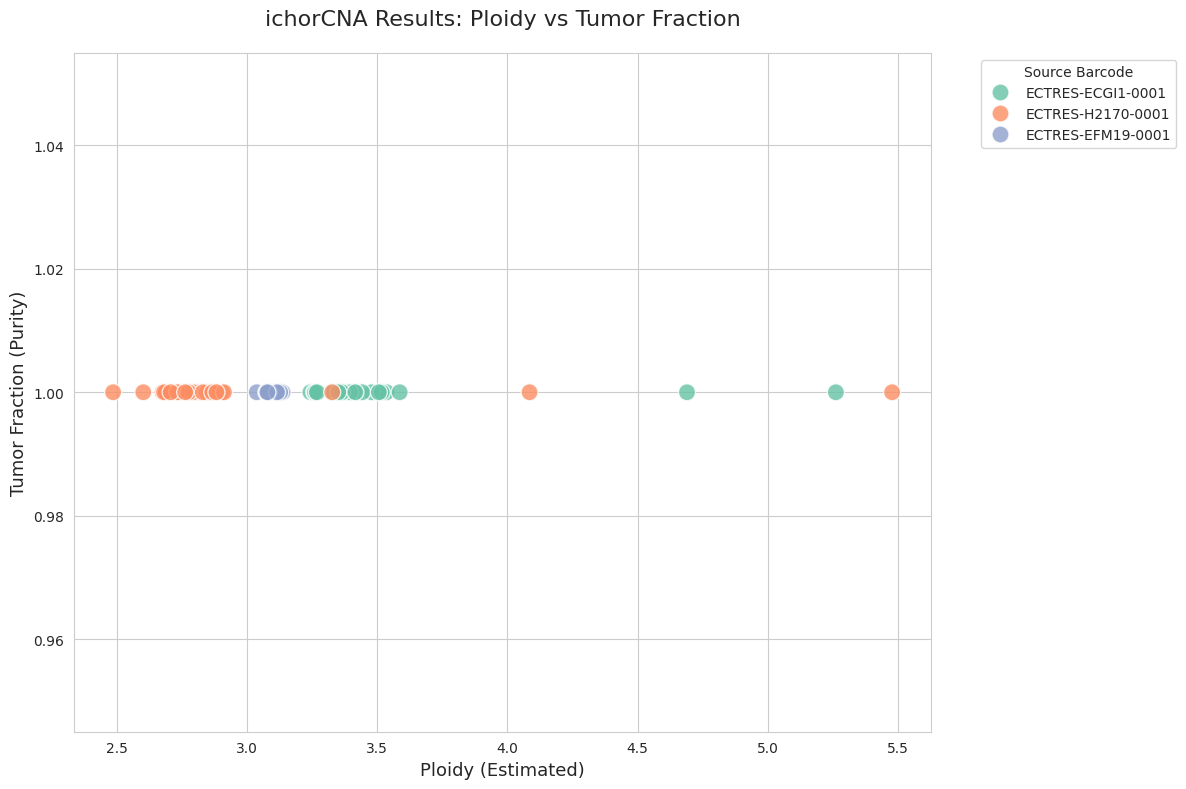

In [47]:
df_ichor=ichor_df.copy()
# 1. 데이터 타입 변환 (숫자형으로 확정)
df_ichor['Ploidy'] = pd.to_numeric(df_ichor['Ploidy'], errors='coerce')
df_ichor['Tumor Fraction'] = pd.to_numeric(df_ichor['Tumor Fraction'], errors='coerce')

# 2. source_barcode 추출 (예: ECTRES-ECGI1-0001-TPX... -> ECTRES-ECGI1-0001)
# 샘플 이름의 구조에 따라 하이픈(-) 기준 앞 3 덩어리를 합칩니다.
df_ichor['source_barcode'] = df_ichor['Sample'].apply(lambda x: "-".join(x.split("-")[:3]))

# 3. 그래프 그리기
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# 산점도 생성
scatter = sns.scatterplot(
    data=df_ichor, 
    x='Ploidy', 
    y='Tumor Fraction', 
    hue='source_barcode', 
    palette='Set2',      # 색상 테마 (샘플이 아주 많으면 'husl'이나 'tab20' 추천)
    s=150,               # 점 크기
    alpha=0.8,           # 투명도
    edgecolor='w'        # 점 테두리 흰색
)

# 4. 그래프 꾸미기
plt.title('ichorCNA Results: Ploidy vs Tumor Fraction', fontsize=16, pad=20)
plt.xlabel('Ploidy (Estimated)', fontsize=13)
plt.ylabel('Tumor Fraction (Purity)', fontsize=13)

# 범례(Legend) 위치 조정 (그래프 밖으로 빼서 가독성 확보)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Source Barcode', fontsize=10)

# 5. 축 범위 자동 조정 및 레이아웃 정리
plt.tight_layout()

# 그래프 저장 (선택 사항)
# plt.savefig('ichorCNA_scatter_plot.png', dpi=300)

plt.show()

In [54]:
df_ichor = ichor_df.copy()

candidate_cols = [
    'Ploidy',
    'Coverage',
    'ChrY coverage fraction',
    'ChrX median log ratio',
    "Student's t mean",
    "Student's t precision",
    'Gamma Rate Init',
    'GC-Map correction MAD'
]

for col in candidate_cols:
    df_ichor[col] = pd.to_numeric(df_ichor[col], errors='coerce')

summary_check = pd.DataFrame({
    'n_non_na': df_ichor[candidate_cols].notna().sum(),
    'n_unique': df_ichor[candidate_cols].nunique(dropna=True),
    'min': df_ichor[candidate_cols].min(),
    'max': df_ichor[candidate_cols].max()
}).sort_values('n_unique', ascending=False)

summary_check

,n_non_na,n_unique,min,max
ChrX median log ratio,77,76,-1.765000,0.332600
GC-Map correction MAD,77,76,0.044970,0.082860
ChrY coverage fraction,77,75,0.000038,0.000747
Ploidy,77,73,2.485000,5.478000
Gamma Rate Init,77,29,0.026000,0.066000
Coverage,0,0,NaN,NaN
Student's t mean,0,0,NaN,NaN
Student's t precision,0,0,NaN,NaN


In [ ]:
# nextflow run main.nf -profile singularity   --input /mnt/NAS3/home/jiwon/ECTRES/manifest/ECTRES_clones_nf_dna_bam.csv   --outdir /mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/results/ichorCNA/v2/   --window 500000   -w /mnt/NAS3/home/jiwon/HL-NF//nxf_work/ichor -resume

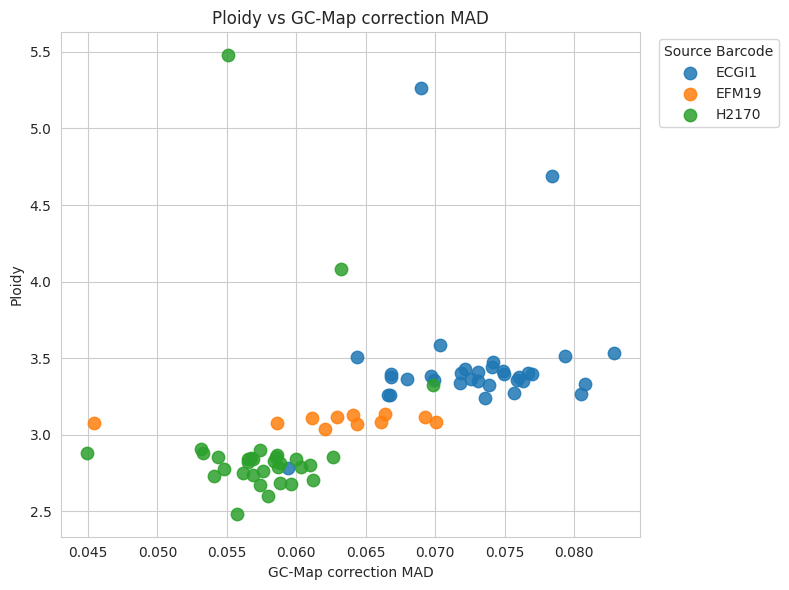

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

df_plot = ichor_df.copy()

# 1. 문자열 공백 제거 후 숫자형 변환
for col in ['Ploidy', 'GC-Map correction MAD']:
    df_plot[col] = (
        df_plot[col]
        .astype(str)
        .str.strip()
        .replace({'nan': pd.NA, 'NA': pd.NA, '': pd.NA})
    )
    df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')

# 2. parental 제외
# df_plot = df_plot[~df_plot['sample_id'].str.contains('parental', case=False, na=False)].copy()

# 3. NA 제거
df_plot = df_plot.dropna(subset=['Ploidy', 'GC-Map correction MAD', 'source_barcode'])

# 4. 그룹별 색 지정
group_order = sorted(df_plot['source_barcode'].dropna().unique())
colors = plt.cm.Set2(range(len(group_order)))
color_map = dict(zip(group_order, colors))

# 5. scatter plot
plt.figure(figsize=(8, 6))

for group in group_order:
    sub = df_plot[df_plot['source_barcode'] == group]
    plt.scatter(
        sub['GC-Map correction MAD'],
        sub['Ploidy'],
        label=group,
        s=80,
        alpha=0.85
    )

plt.xlabel('GC-Map correction MAD')
plt.ylabel('Ploidy')
plt.title('Ploidy vs GC-Map correction MAD')
plt.legend(title='Source Barcode', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

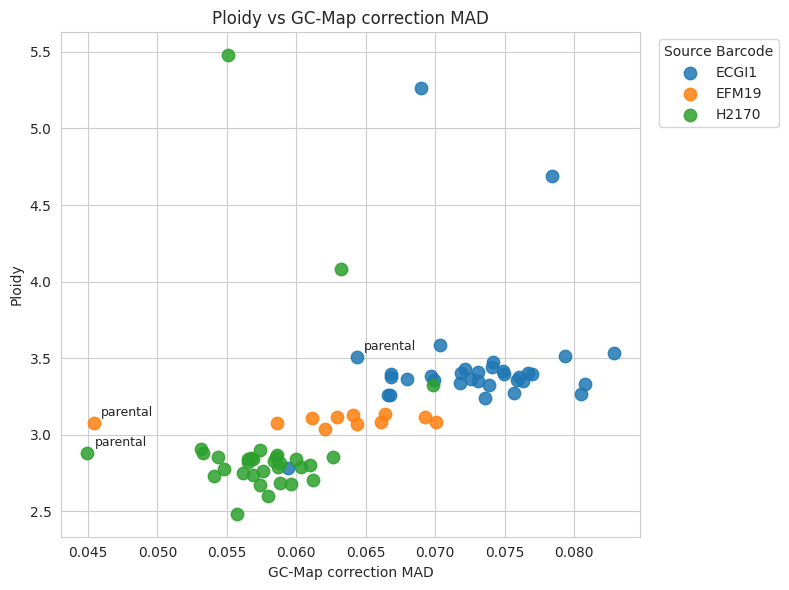

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

df_plot = ichor_df.copy()

# 1. 문자열 공백 제거 후 숫자형 변환
for col in ['Ploidy', 'GC-Map correction MAD']:
    df_plot[col] = (
        df_plot[col]
        .astype(str)
        .str.strip()
        .replace({'nan': pd.NA, 'NA': pd.NA, '': pd.NA})
    )
    df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')

# 2. NA 제거
df_plot = df_plot.dropna(subset=['Ploidy', 'GC-Map correction MAD', 'source_barcode', 'sample_id'])

# 3. 그룹 순서
group_order = sorted(df_plot['source_barcode'].dropna().unique())

# 4. scatter plot
plt.figure(figsize=(8, 6))

for group in group_order:
    sub = df_plot[df_plot['source_barcode'] == group]
    plt.scatter(
        sub['GC-Map correction MAD'],
        sub['Ploidy'],
        label=group,
        s=80,
        alpha=0.85
    )

# 5. parental 샘플만 annotation
parental_df = df_plot[df_plot['sample_id'].str.contains('parental', case=False, na=False)].copy()

for _, row in parental_df.iterrows():
    plt.annotate(
        row['sample_id'],
        (row['GC-Map correction MAD'], row['Ploidy']),
        xytext=(5, 5),          # 점에서 살짝 오른쪽 위
        textcoords='offset points',
        fontsize=9
    )

plt.xlabel('GC-Map correction MAD')
plt.ylabel('Ploidy')
plt.title('Ploidy vs GC-Map correction MAD')
plt.legend(title='Source Barcode', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [61]:
q1 = df_plot['GC-Map correction MAD'].quantile(0.25)
q3 = df_plot['GC-Map correction MAD'].quantile(0.75)
iqr = q3 - q1
cutoff = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Suggested outlier cutoff:", cutoff)

df_plot['MAD_outlier'] = df_plot['GC-Map correction MAD'] > cutoff
df_plot[['sample_id', 'source_barcode', 'GC-Map correction MAD', 'Ploidy', 'MAD_outlier']].sort_values(
    'GC-Map correction MAD', ascending=False
).head(15)

Q1: 0.05856
Q3: 0.07294
IQR: 0.014380000000000004
Suggested outlier cutoff: 0.09451000000000001


,sample_id,source_barcode,GC-Map correction MAD,Ploidy,MAD_outlier
13,EG_18,ECGI1,0.08286,3.536,False
18,EG_26,ECGI1,0.08074,3.332,False
26,EG_3,ECGI1,0.08051,3.268,False
29,EG_6,ECGI1,0.07935,3.517,False
23,EG_5,ECGI1,0.07840,4.690,False
2,EG_27,ECGI1,0.07693,3.398,False
10,EG_8,ECGI1,0.07665,3.401,False
31,EG_11,ECGI1,0.07633,3.350,False
3,EG_29,ECGI1,0.07600,3.380,False
28,EG_4,ECGI1,0.07590,3.360,False


In [77]:
df_plot.head(2)
df_plot[(df_plot['source_barcode']=='H2170')&(df_plot['Ploidy']>3)]

ichor_df[(ichor_df['sample_id']=='parental')&(ichor_df['source_barcode']=='EFM19')]

,Sample,Gender,Tumor Fraction,Ploidy,Subclone Fraction,Fraction Genome Subclonal,Fraction CNA Subclonal,Coverage,ChrY coverage fraction,ChrX median log ratio,Student's t mean,Student's t precision,Gamma Rate Init,GC-Map correction MAD,aliquot_barcode,source_barcode,sample_id
76,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,female,1,3.078,NA,0,0,NA,5.387e-05,0.3302,"-1.1, -0.43, -0.026, 0.26, 0.49, 0.67, 0.82","280, 660, 840, 530, 280, 13, 2.3",0.049,0.04543,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,EFM19,parental
